# 📊 OLP Data Analysis — Step-by-Step Teaching Notebook
### Project: Performance Predictor & Success Profile Analyser | Internship

---

## 🗺️ What This Notebook Covers

| Step | Topic | What You'll Learn |
|------|--------|--------------------|
| 1 | Setup & Load | How to load Excel data into Python |
| 2 | Data Audit | Shape, columns, missing values — your first look |
| 3 | Data Cleaning | Fix types, handle nulls, create new columns |
| 4 | Univariate Analysis | Understand each column individually |
| 5 | Bivariate Analysis | How two variables relate to each other |
| 6 | Rating Trend Analysis | How performance evolved over 5 years |
| 7 | Competency Proxies | Engineering variables for your scoring tool |
| 8 | Success Profile Building | Who are the top performers? What do they look like? |
| 9 | Visualisations | Charts for your HR Head presentation |
| 10 | Key Inferences Summary | What all this means for your project |

---

> **Dataset:** OLP_Data.xlsx | 920 employees × 27 columns | Reliance Industries IT workforce  
> **Purpose:** Build competency-based performance predictor for HR Manager & HRBP roles

---
## STEP 1 — Setup & Load
### 🎓 Concept: Why we import libraries first

Think of libraries as your **toolbox**:
- `pandas` → Excel/table operations (your data wrangling engine)
- `numpy` → Math operations
- `matplotlib` + `seaborn` → Charts and visualisations
- `warnings` → Suppress unnecessary warnings so output is clean

**Always run this cell first before anything else.**

In [93]:
# ── CELL 1.1: Import all libraries ──────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')          # Suppress minor warnings
pd.set_option('display.max_columns', 30)   # Show all columns in output
pd.set_option('display.max_colwidth', 50)  # Truncate long text nicely
sns.set_theme(style='whitegrid', palette='muted')  # Clean chart style

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


In [94]:
import pandas as pd

df = pd.read_excel(r"C:\Users\Vivek267.Kumar\Downloads\Employee Data and Performance History\OLP Data.xlsx")

print(f'✅ Data loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

✅ Data loaded: 920 rows × 27 columns
Columns: ['SrNo', 'Emp.Code', 'Cohort', 'Name', 'Org.Unit', 'Position Text', 'Job ID', 'Job Role', 'H R', 'HRBP Name', 'Marital Status', 'DOJ', 'Age (YY.MM)', 'DOB', 'Current Grade', 'Current Designation', 'RilExp YY.MM', 'Prev Exp YY.MM', 'Tot Exp YY.MM', 'DOL PROM', 'DOL PROGRESSION', 'RTG21-22', 'RTG22-23', 'RTG23-24', 'RTG24-25', 'RTG25-26', 'Qualification']


---
## STEP 2 — Data Audit (First Look)
### 🎓 Concept: Before any analysis, ALWAYS audit your data

A **Data Audit** answers 4 questions:
1. **Shape** — How many rows and columns?
2. **Types** — Is each column the right data type?
3. **Missing** — Which columns have blank/null values?
4. **Preview** — Does the data look sensible?

Skipping this step causes wrong analysis later. Senior analysts never skip it.

In [131]:
# ── CELL 2.1: Preview the first 5 rows ──────────────────────────────────
# .head(n) shows the first n rows — your first visual scan of the data

df.head(5)

,SrNo,Emp.Code,Cohort,Name,Org.Unit,Position Text,Job ID,Job Role,H R,HRBP Name,Marital Status,DOJ,Age (YY.MM),DOB,Current Grade,...,age_group,seniority_tier,was_promoted,had_progression,perf_trajectory,score_avg_rating,score_trend,score_consistency,score_exp,score_recency_rtg,score_promotion,score_progression,composite_score,performance_tier,is_top_performer
0,1,3629,Enterprise Security Platform,Mr. P N S Vijayakumar,E&M IT ESP Project Delivery,Chief Software Development,24281770,Chief Software Development,Bharat Bhushan,Ms. Sudeshna Das,Marrd.,2002-07-06,53.1,1972-08-06,Vice President,...,50-60,Leadership,1,0,Consistent Star,91.43,50.0,74.19,62.52,96.25,100,0,76.56,Exceeds,1
1,2,7214,IT Infrastructure,Mr. Suresh Kumar,Infrastructure Projects,Chief - IT Infrastructure,24281819,Chief IT Infrastructure,Bharat Bhushan,Ms. Sudeshna Das,Marrd.,1994-01-14,56.9,1969-08-18,Vice President,...,50-60,Leadership,1,1,Rising Performer,82.85,75.0,68.36,87.77,93.75,100,100,83.89,Exceeds,1
2,3,12514,IT Infrastructure,Mr. Ashok H Dhaundiyal,Collaboration Tools,Team Lead IT Infrastructure,24281817,Team Lead IT Infrastructure,Bharat Bhushan,Ms. Sudeshna Das,Marrd.,1994-10-01,58.5,1967-12-24,General Manager,...,50-60,Senior,1,1,Developing,48.56,25.0,74.19,86.14,67.50,100,100,61.56,Meets Expectation,0
3,4,12714,IT Infrastructure,Mr. Santosh G Rane,Infrastructure Projects,Lead IT Infrastructure,24281816,Lead IT Infrastructure,Bharat Bhushan,Ms. Sudeshna Das,Marrd.,1994-10-01,52.8,1973-10-05,DGM,...,50-60,Senior,1,1,Solid Performer,65.71,50.0,74.19,86.14,81.25,100,100,73.21,Exceeds,1
4,5,15114,IRM & Cyber Security,Mr. Michael G Kohli,IRM End Point Security,Head Information Security,24281827,Head Information Security,Bharat Bhushan,Ms. Sudeshna Das,Marrd.,1995-03-01,55.4,1971-02-06,Asst. Vice President,...,50-60,Leadership,1,1,Developing,48.56,50.0,74.19,84.78,71.25,100,100,65.92,Meets Expectation,0


In [132]:
unique_count = df.nunique()
unique_count

SrNo                    920
Emp.Code                920
Cohort                   12
Name                    917
Org.Unit                 83
Position Text           132
Job ID                  109
Job Role                108
H R                       1
HRBP Name                 4
Marital Status            5
DOJ                     572
Age (YY.MM)             337
DOB                     873
Current Grade            13
Current Designation      17
RilExp YY.MM            235
Prev Exp YY.MM          188
Tot Exp YY.MM           293
DOL PROM                 62
DOL PROGRESSION          32
RTG21-22                  4
RTG22-23                  4
RTG23-24                  4
RTG24-25                  4
RTG25-26                  4
Qualification           827
RTG21-22_num              4
RTG22-23_num              4
RTG23-24_num              4
RTG24-25_num              4
RTG25-26_num              4
avg_rating               24
rating_trend              5
rating_consistency       15
recency_weighted_rtg

In [133]:

for col in df.columns:
    unique_vals = df[col].dropna().unique().tolist()

    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(f"Unique Count: {len(unique_vals)}")
    print(f"Unique Values: {unique_vals}")


Column: SrNo
Unique Count: 920
Unique Values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 

In [125]:
# ── CELL 2.2: Check data types ───────────────────────────────────────────
# .dtypes tells you whether each column is text (object), number (int/float),
# or date (datetime64). Wrong types = wrong analysis.

print('=== DATA TYPES ===')
print(df.dtypes)

# 📌 INTERPRETATION GUIDE:
# object      → text / categorical
# int64       → whole numbers
# float64     → decimal numbers
# datetime64  → dates

# 🔍 WHAT WE NOTICE IN OLP DATA:
# - 'Prev Exp YY.MM' is 'object' (string) but should be numeric → needs fixing
# - DOJ, DOB, DOL PROM, DOL PROGRESSION are already datetime → good
# - RTG columns are object (text ratings like A+, A, A*) → need encoding

=== DATA TYPES ===
SrNo                             int64
Emp.Code                         int64
Cohort                          object
Name                            object
Org.Unit                        object
Position Text                   object
Job ID                           int64
Job Role                        object
H R                             object
HRBP Name                       object
Marital Status                  object
DOJ                     datetime64[ns]
Age (YY.MM)                    float64
DOB                     datetime64[ns]
Current Grade                   object
Current Designation             object
RilExp YY.MM                   float64
Prev Exp YY.MM                 float64
Tot Exp YY.MM                  float64
DOL PROM                datetime64[ns]
DOL PROGRESSION         datetime64[ns]
RTG21-22                        object
RTG22-23                        object
RTG23-24                        object
RTG24-25                        object
RTG25-

In [97]:
# ── CELL 2.3: Check missing values ──────────────────────────────────────
# .isnull().sum() counts empty cells per column
# We also calculate the % missing — that determines how to handle it

missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('=== MISSING VALUE REPORT ===')
print(missing)

# 📌 INTERPRETATION:
# DOL PROM:       81.2% missing → Most employees haven't been promoted
# DOL PROGRESSION: 63.8% missing → Most haven't had a grade progression
# RTG21-22:       43.1% missing → Many employees joined after 2021-22
# RTG22-23:       23.2% missing → Fewer missing as employee base stabilised
# RTG23-24:        5.4% missing → Near complete coverage
# RTG24-25, 25-26: ~1% missing  → Almost complete — these are your primary rating cols

=== MISSING VALUE REPORT ===
                 Missing Count  Missing %
DOL PROM                   747      81.20
DOL PROGRESSION            587      63.80
RTG21-22                   397      43.15
RTG22-23                   213      23.15
RTG23-24                    50       5.43
Cohort                      37       4.02
RTG24-25                     8       0.87
RTG25-26                     2       0.22
Qualification                2       0.22


In [98]:
# ── CELL 2.4: Statistical summary of numeric columns ────────────────────
# .describe() gives count, mean, std, min, quartiles, max
# This is your numeric data health check

print('=== NUMERIC COLUMN SUMMARY ===')
df[['Age (YY.MM)', 'RilExp YY.MM', 'Tot Exp YY.MM']].describe().round(2)

=== NUMERIC COLUMN SUMMARY ===


,Age (YY.MM),RilExp YY.MM,Tot Exp YY.MM
count,920.00,920.00,920.00
mean,36.51,8.93,13.21
std,9.91,7.45,9.50
min,22.40,0.11,1.11
25%,26.48,3.11,4.10
50%,35.95,6.10,11.90
75%,44.10,13.10,19.90
max,69.10,36.90,44.40


In [99]:
# ── CELL 2.5: Unique value count for categorical columns ─────────────────
# .nunique() tells you how many distinct values exist in each text column
# High nunique = high cardinality (like names) → usually not useful for grouping
# Low nunique = good for grouping/aggregation

cat_cols = df.select_dtypes(include='object').columns
print('=== UNIQUE VALUES PER CATEGORICAL COLUMN ===')
for col in cat_cols:
    print(f'  {col}: {df[col].nunique()} unique values')

=== UNIQUE VALUES PER CATEGORICAL COLUMN ===
  Cohort: 12 unique values
  Name: 917 unique values
  Org.Unit: 83 unique values
  Position Text: 132 unique values
  Job Role: 108 unique values
  H R: 1 unique values
  HRBP Name: 4 unique values
  Marital Status: 5 unique values
  Current Grade: 13 unique values
  Current Designation: 17 unique values
  Prev Exp YY.MM: 201 unique values
  RTG21-22: 4 unique values
  RTG22-23: 4 unique values
  RTG23-24: 4 unique values
  RTG24-25: 4 unique values
  RTG25-26: 4 unique values
  Qualification: 827 unique values


---
## STEP 3 — Data Cleaning
### 🎓 Concept: Transform raw data into analysis-ready data

Cleaning has 4 tasks:
1. **Fix data types** — convert text to numbers where needed
2. **Handle missing values** — drop, fill, or flag
3. **Encode categorical variables** — convert A+, A, A* into numbers
4. **Engineer new features** — create columns that didn't exist but are analytically useful

**Rule of thumb:** Never modify the original `df` before saving a backup.

In [100]:
# ── CELL 3.1: Save a clean copy ─────────────────────────────────────────
# Always work on a copy — preserve raw data for reference

df_raw = df.copy()   # Raw backup — never touch this
df = df.copy()       # Working copy — all changes go here

print('✅ Backup saved as df_raw')

✅ Backup saved as df_raw


In [101]:
# ── CELL 3.2: Fix 'Prev Exp YY.MM' column (text → numeric) ─────────────
# This column has values like '9', '1.8', '.' (dot means 0)
# pd.to_numeric(errors='coerce') converts numbers, turns non-numbers into NaN

df['Prev Exp YY.MM'] = pd.to_numeric(df['Prev Exp YY.MM'], errors='coerce').fillna(0)

print('✅ Prev Exp fixed. Sample values:')
print(df['Prev Exp YY.MM'].describe().round(2))

✅ Prev Exp fixed. Sample values:
count    920.00
mean       4.28
std        5.33
min        0.00
25%        0.00
50%        2.80
75%        6.82
max       38.10
Name: Prev Exp YY.MM, dtype: float64


In [102]:
# ── CELL 3.3: Encode Performance Ratings (Text → Numbers) ───────────────
# The rating system is ordinal: A* > A+ > A > B
# We map them to numbers so we can calculate averages, correlations
#
# Why this order? A* is the highest rating (exceptional), A+ is next,
# then A (meets expectation), B is below expectation

rating_map = {'A*': 4, 'A+': 3, 'A': 2, 'B': 1}

rating_cols = ['RTG21-22', 'RTG22-23', 'RTG23-24', 'RTG24-25', 'RTG25-26']
for col in rating_cols:
    df[col + '_num'] = df[col].map(rating_map)

print('✅ Ratings encoded. Sample:')
df[['RTG24-25', 'RTG24-25_num', 'RTG25-26', 'RTG25-26_num']].head(5)

✅ Ratings encoded. Sample:


,RTG24-25,RTG24-25_num,RTG25-26,RTG25-26_num
0,A*,4.0,A*,4.0
1,A*,4.0,A*,4.0
2,A+,3.0,A,2.0
3,A*,4.0,A+,3.0
4,A+,3.0,A+,3.0


In [103]:
# ── CELL 3.4: Engineer new analytical features ───────────────────────────
# Feature Engineering = creating new columns that give us more analytical power
# These are not in the original data — we derive them from existing columns

# 1. Average Rating across all available years
num_rating_cols = [c for c in df.columns if c.endswith('_num')]
df['avg_rating'] = df[num_rating_cols].mean(axis=1).round(3)

# 2. Rating Trend: Did the person improve over time?
#    Positive = improved | Zero = stable | Negative = declined
df['rating_trend'] = df['RTG25-26_num'] - df['RTG21-22_num']

# 3. Performance Consistency: Low std = consistently performing
df['rating_consistency'] = df[num_rating_cols].std(axis=1).round(3)

# 4. Recency-Weighted Rating (recent years matter more)
#    Give more weight to recent performance
df['recency_weighted_rtg'] = (
    df['RTG21-22_num'].fillna(0) * 0.10 +
    df['RTG22-23_num'].fillna(0) * 0.15 +
    df['RTG23-24_num'].fillna(0) * 0.20 +
    df['RTG24-25_num'].fillna(0) * 0.25 +
    df['RTG25-26_num'].fillna(0) * 0.30
).round(3)

# 5. Age Group for segmentation
df['age_group'] = pd.cut(
    df['Age (YY.MM)'],
    bins=[20, 30, 40, 50, 60, 75],
    labels=['20-30', '30-40', '40-50', '50-60', '60+']
)

# 6. Seniority Tier (grouped grades)
senior_map = {
    'Assistant Manager': 'Junior', 'Deputy Manager': 'Junior', 'Executive': 'Junior',
    'Sr.Manager': 'Mid', 'Manager': 'Mid', 'Senior Executive': 'Mid',
    'DGM': 'Senior', 'General Manager': 'Senior',
    'Asst. Vice President': 'Leadership', 'Vice President': 'Leadership',
    'Sr.Vice President': 'Leadership', 'Exe.Vice President': 'Leadership', 'President': 'Leadership'
}
df['seniority_tier'] = df['Current Grade'].map(senior_map).fillna('Other')

# 7. Has been promoted? (Binary flag from DOL PROM)
df['was_promoted'] = df['DOL PROM'].notna().astype(int)

# 8. Has had progression? (Grade progression flag)
df['had_progression'] = df['DOL PROGRESSION'].notna().astype(int)

print('✅ New features created:')
new_features = ['avg_rating','rating_trend','rating_consistency','recency_weighted_rtg',
                'age_group','seniority_tier','was_promoted','had_progression']
df[new_features].head(5)

✅ New features created:


,avg_rating,rating_trend,rating_consistency,recency_weighted_rtg,age_group,seniority_tier,was_promoted,had_progression
0,3.8,0.0,0.447,3.85,50-60,Leadership,1,0
1,3.6,1.0,0.548,3.75,50-60,Leadership,1,1
2,2.8,-1.0,0.447,2.70,50-60,Senior,1,1
3,3.2,0.0,0.447,3.25,50-60,Senior,1,1
4,2.8,0.0,0.447,2.85,50-60,Leadership,1,1


---
## STEP 4 — Univariate Analysis
### 🎓 Concept: Understand EACH column individually before comparing them

**Univariate** = one variable at a time.

For **categorical** columns → use `value_counts()` + bar chart  
For **numeric** columns → use `describe()` + histogram/boxplot  

Goal: Understand the *distribution* and *spread* of each key variable.

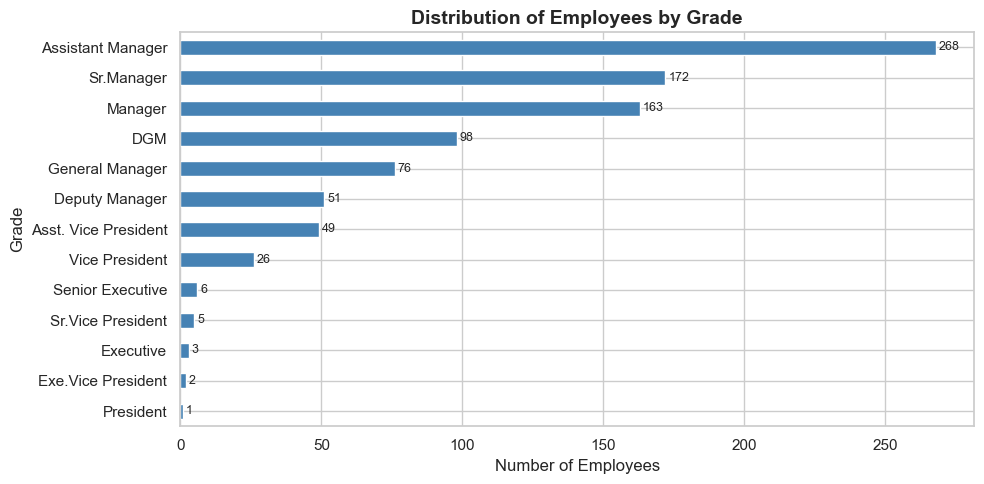


Grade Distribution %:
Current Grade
Assistant Manager       29.1
Sr.Manager              18.7
Manager                 17.7
DGM                     10.7
General Manager          8.3
Deputy Manager           5.5
Asst. Vice President     5.3
Vice President           2.8
Senior Executive         0.7
Sr.Vice President        0.5
Executive                0.3
Exe.Vice President       0.2
President                0.1
Name: count, dtype: float64


In [104]:
# ── CELL 4.1: Grade/Seniority Distribution ───────────────────────────────
# value_counts() counts how many rows fall in each category
# normalize=True gives percentage instead of count

grade_counts = df['Current Grade'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
grade_counts.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Employees by Grade', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Employees')
ax.set_ylabel('Grade')
for i, v in enumerate(grade_counts.sort_values()):
    ax.text(v + 1, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

# 📌 INTERPRETATION:
# - Assistant Manager is the largest group (268 = 29%)
# - This is an IT-heavy, predominantly junior-mid level workforce
# - Pyramid shape = healthy organisational structure
print('\nGrade Distribution %:')
print((grade_counts / len(df) * 100).round(1))

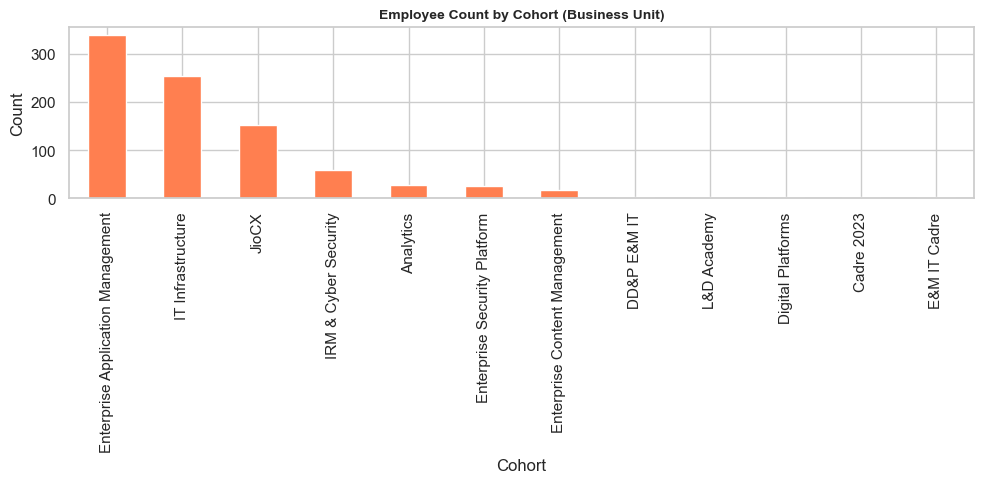

In [140]:
# ── CELL 4.2: Cohort Distribution ────────────────────────────────────────
# Which business unit (cohort) has the most employees?

cohort_counts = df['Cohort'].value_counts().dropna()

fig, ax = plt.subplots(figsize=(10,5))
cohort_counts.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Employee Count by Cohort (Business Unit)', fontsize=10, fontweight='bold')
ax.set_xlabel('Cohort')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

# 📌 INTERPRETATION:
# Enterprise Application Management (339) = largest cohort
# IT Infrastructure (253) = second largest
# Cohorts are the business units this OLP covers

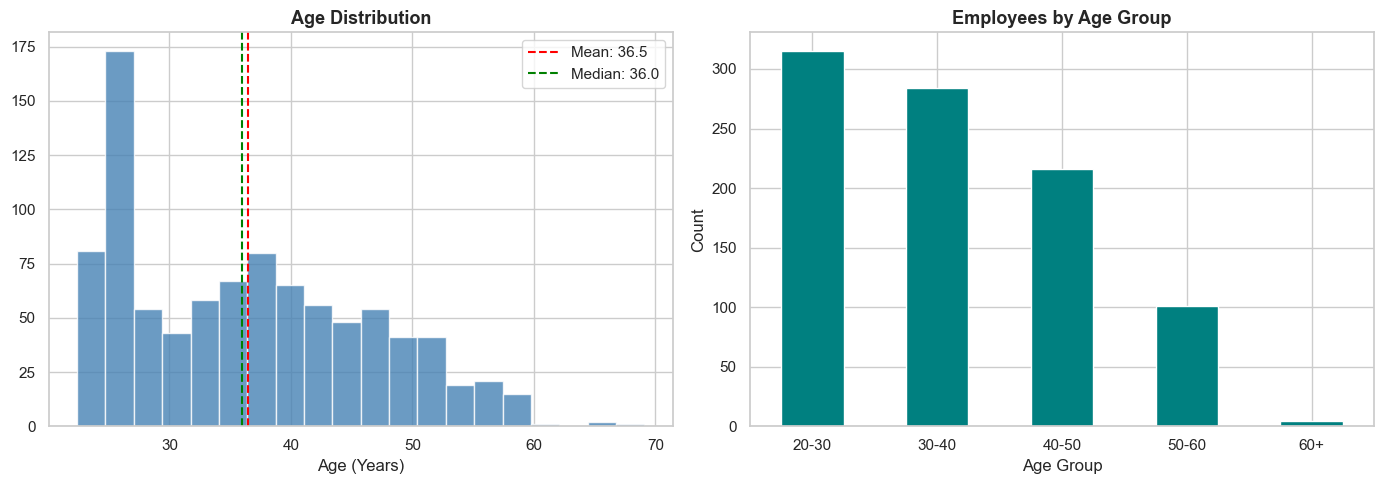

Mean Age: 36.5 | Median: 36.0
Youngest: 22.4 | Oldest: 69.1


In [106]:
# ── CELL 4.3: Age Distribution ───────────────────────────────────────────
# Histogram shows the shape of a numeric distribution
# KDE (Kernel Density Estimate) = smooth curve showing the trend

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Age (YY.MM)'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['Age (YY.MM)'].mean(), color='red', linestyle='--', label=f'Mean: {df["Age (YY.MM)"].mean():.1f}')
axes[0].axvline(df['Age (YY.MM)'].median(), color='green', linestyle='--', label=f'Median: {df["Age (YY.MM)"].median():.1f}')
axes[0].set_title('Age Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age (Years)')
axes[0].legend()

# Age group bar chart
df['age_group'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Employees by Age Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f'Mean Age: {df["Age (YY.MM)"].mean():.1f} | Median: {df["Age (YY.MM)"].median():.1f}')
print(f'Youngest: {df["Age (YY.MM)"].min():.1f} | Oldest: {df["Age (YY.MM)"].max():.1f}')

# 📌 INTERPRETATION:
# Bimodal-ish distribution — two clusters: young hires (22-30) and experienced (40-55)
# 20-30 age group is largest → predominantly younger workforce
# This matters for performance predictor: age ≠ performance, but experience does

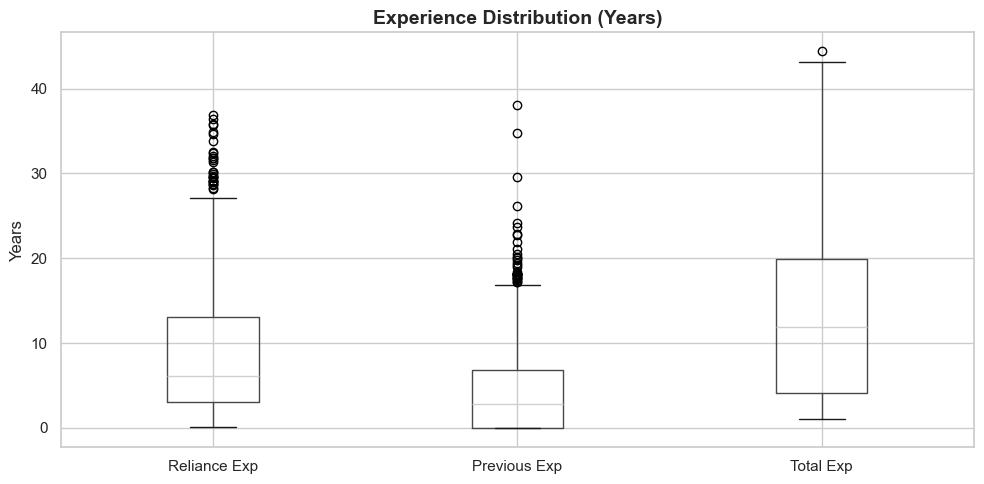

Experience Stats (years):
       Reliance Exp  Previous Exp  Total Exp
count        920.00        920.00     920.00
mean           8.93          4.28      13.21
std            7.45          5.33       9.50
min            0.11          0.00       1.11
25%            3.11          0.00       4.10
50%            6.10          2.80      11.90
75%           13.10          6.82      19.90
max           36.90         38.10      44.40


In [107]:
# ── CELL 4.4: Experience Distribution ────────────────────────────────────
# Three experience columns: Reliance Exp, Previous Exp, Total Exp
# Boxplot is great for spotting outliers and comparing spread

fig, ax = plt.subplots(figsize=(10, 5))
exp_data = df[['RilExp YY.MM', 'Prev Exp YY.MM', 'Tot Exp YY.MM']].rename(
    columns={'RilExp YY.MM': 'Reliance Exp', 'Prev Exp YY.MM': 'Previous Exp', 'Tot Exp YY.MM': 'Total Exp'}
)
exp_data.boxplot(ax=ax)
ax.set_title('Experience Distribution (Years)', fontsize=14, fontweight='bold')
ax.set_ylabel('Years')
plt.tight_layout()
plt.show()

print('Experience Stats (years):')
print(exp_data.describe().round(2))

# 📌 INTERPRETATION:
# Median Reliance Exp = ~6 yrs → many are relatively new to Reliance
# Median Total Exp = ~12 yrs → brings prior experience
# Boxplot whiskers = range; dots beyond = outliers (veterans with 30+ yrs)
# Wide IQR on Total Exp = diverse experience levels in this workforce

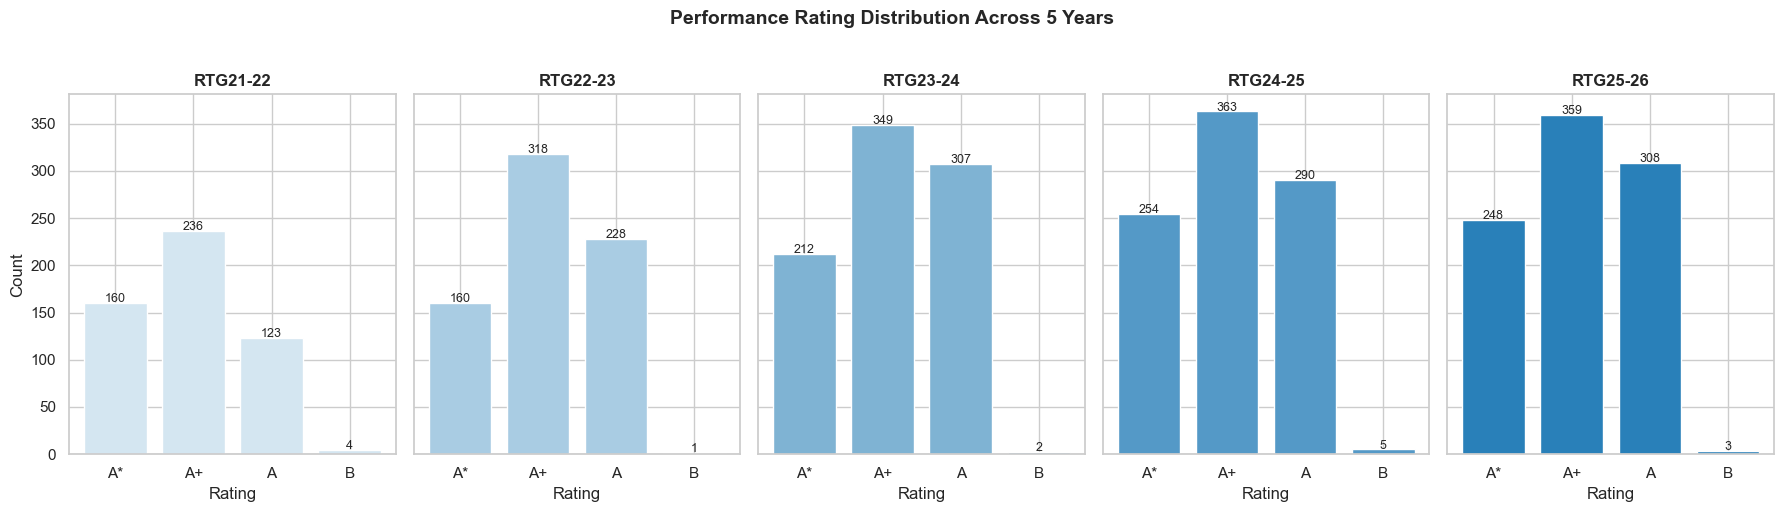

In [108]:
# ── CELL 4.5: Performance Rating Distribution (All 5 Years) ──────────────
# How are employees rated across years? Is the distribution shifting?

fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=True)
colors = ['#d4e6f1', '#a9cce3', '#7fb3d3', '#5499c7', '#2980b9']

for i, col in enumerate(rating_cols):
    counts = df[col].value_counts().reindex(['A*', 'A+', 'A', 'B']).fillna(0)
    axes[i].bar(counts.index, counts.values, color=colors[i], edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Rating')
    if i == 0:
        axes[i].set_ylabel('Count')
    for j, v in enumerate(counts.values):
        if v > 0:
            axes[i].text(j, v + 1, int(v), ha='center', fontsize=9)

plt.suptitle('Performance Rating Distribution Across 5 Years', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 📌 INTERPRETATION:
# A* recipients = exceptional performers (highest band)
# A+ is the modal rating (most common) — most employees meet-and-exceed
# B ratings are very rare = low performers rarely remain
# Distribution expanding over years = more employees getting rated as data matures
# This is a HIGH-PERFORMING workforce — important baseline for success profile

---
## STEP 5 — Bivariate Analysis
### 🎓 Concept: How do two variables relate to each other?

**Bivariate** = two variables together.

Key questions here:
- Does more experience → higher rating?
- Do certain grades → higher performance consistency?
- Does cohort membership affect rating patterns?

Tools: `groupby()`, `corr()`, scatter plots, grouped bar charts

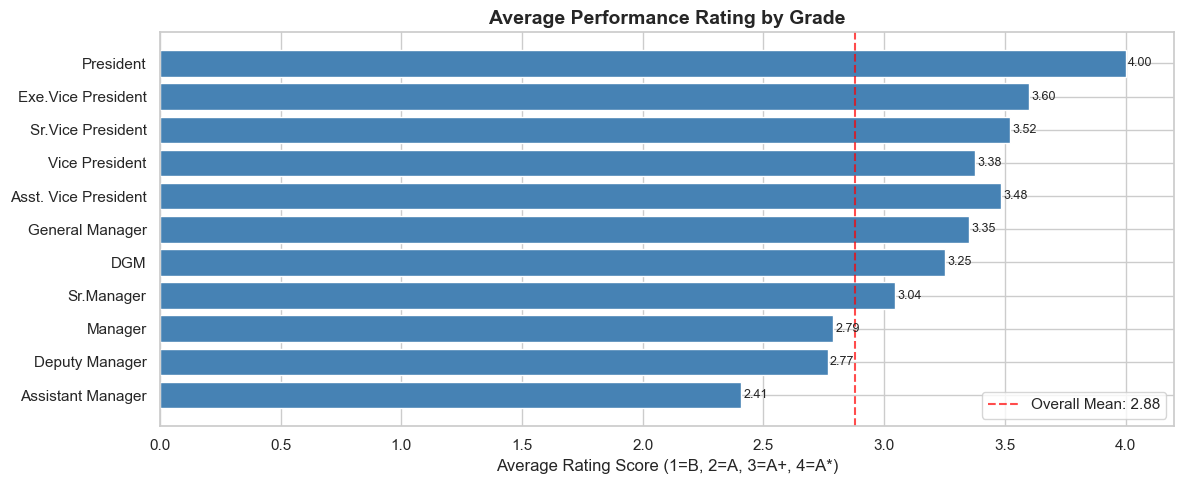

In [109]:
# ── CELL 5.1: Average Rating by Grade ────────────────────────────────────
# groupby() splits the data by a category, then aggregates
# This is the most used pandas operation in HR analytics

grade_order = ['Assistant Manager','Deputy Manager','Manager','Sr.Manager',
               'DGM','General Manager','Asst. Vice President','Vice President',
               'Sr.Vice President','Exe.Vice President','President']

grade_rating = df.groupby('Current Grade')['avg_rating'].mean().reindex(
    [g for g in grade_order if g in df['Current Grade'].unique()]
).dropna()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(grade_rating.index, grade_rating.values, color='steelblue', edgecolor='white')
ax.axvline(df['avg_rating'].mean(), color='red', linestyle='--', alpha=0.7, label=f'Overall Mean: {df["avg_rating"].mean():.2f}')
ax.set_title('Average Performance Rating by Grade', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Rating Score (1=B, 2=A, 3=A+, 4=A*)')
ax.legend()
for bar, val in zip(bars, grade_rating.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# 📌 INFERENCE 1 (Project-Critical):
# Strong positive correlation between grade and rating
# President → 4.0 (A*), Assistant Manager → 2.4 (between A and A+)
# For success profile: HIGH PERFORMERS CLUSTER IN SENIOR GRADES
# This validates that our predictor should weight seniority/grade as a variable

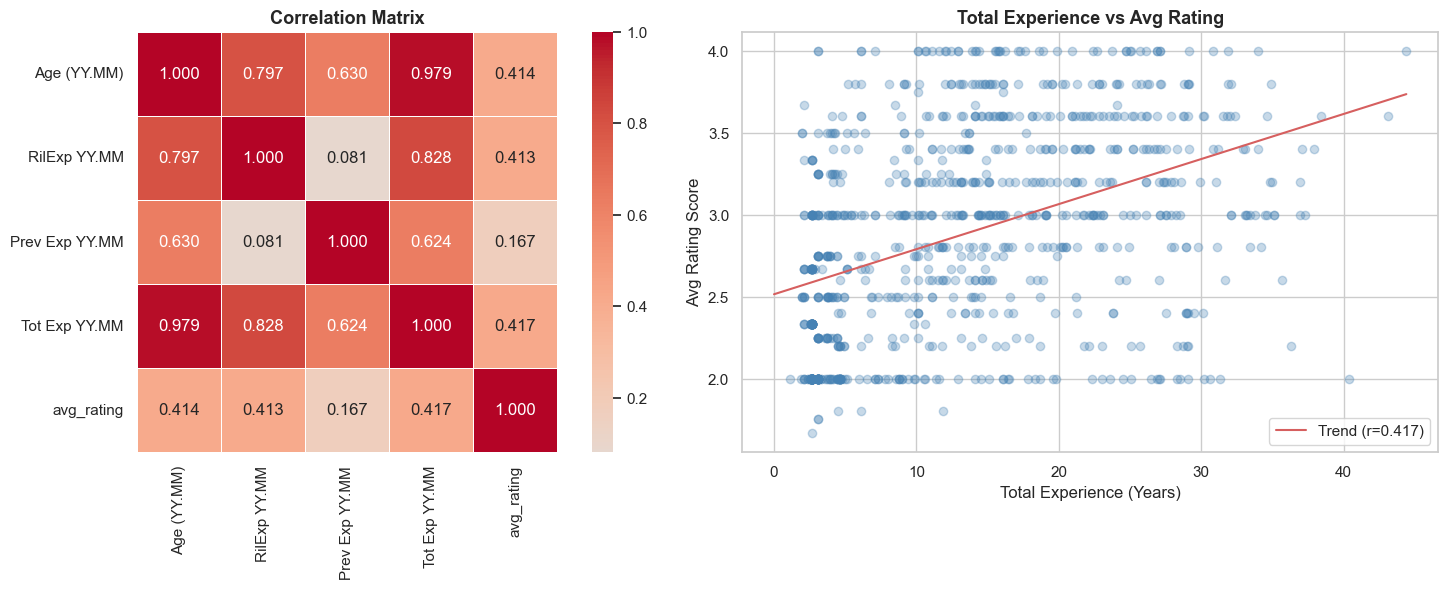

In [110]:
# ── CELL 5.2: Experience vs Rating Correlation ────────────────────────────
# Correlation tells us: as X goes up, does Y go up (positive) or down (negative)?
# Range: -1 (perfect negative) to +1 (perfect positive) | 0 = no relationship
# Rule of thumb: |r| < 0.2 = weak | 0.2-0.5 = moderate | > 0.5 = strong

corr_data = df[['Age (YY.MM)', 'RilExp YY.MM', 'Prev Exp YY.MM', 'Tot Exp YY.MM', 'avg_rating']].dropna()
corr_matrix = corr_data.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap of correlations
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            ax=axes[0], linewidths=0.5, square=True)
axes[0].set_title('Correlation Matrix', fontsize=13, fontweight='bold')

# Scatter: Total Experience vs Avg Rating
scatter_data = df[['Tot Exp YY.MM','avg_rating']].dropna()
axes[1].scatter(scatter_data['Tot Exp YY.MM'], scatter_data['avg_rating'], alpha=0.3, color='steelblue')
m, b = np.polyfit(scatter_data['Tot Exp YY.MM'], scatter_data['avg_rating'], 1)
x_line = np.linspace(0, scatter_data['Tot Exp YY.MM'].max(), 100)
axes[1].plot(x_line, m*x_line + b, 'r-', label=f'Trend (r={corr_matrix.loc["Tot Exp YY.MM","avg_rating"]:.3f})')
axes[1].set_title('Total Experience vs Avg Rating', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Experience (Years)')
axes[1].set_ylabel('Avg Rating Score')
axes[1].legend()

plt.tight_layout()
plt.show()

# 📌 INFERENCE 2:
# r = 0.41 between Total Experience and Avg Rating → MODERATE POSITIVE
# More experienced employees tend to get higher ratings
# BUT correlation ≠ causation — grade also drives both
# For your predictor: experience is a valid input variable with moderate predictive power

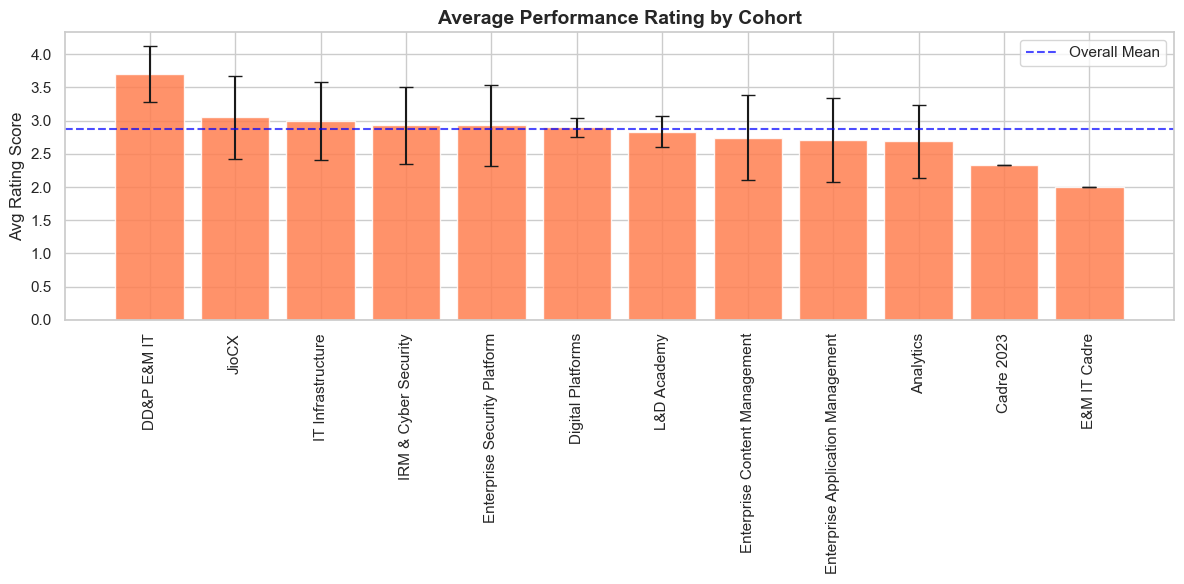

                                   Avg Rating  Std Dev  Count
Cohort                                                       
DD&P E&M IT                             3.700    0.424      2
JioCX                                   3.049    0.619    153
IT Infrastructure                       2.995    0.585    252
IRM & Cyber Security                    2.929    0.582     59
Enterprise Security Platform            2.927    0.606     25
Digital Platforms                       2.900    0.141      2
L&D Academy                             2.834    0.235      2
Enterprise Content Management           2.746    0.635     17
Enterprise Application Management       2.712    0.629    339
Analytics                               2.690    0.553     27
Cadre 2023                              2.333    0.000      2
E&M IT Cadre                            2.000    0.000      2


In [141]:
# ── CELL 5.3: Rating by Cohort (Business Unit) ───────────────────────────
# Which cohorts produce the highest performers?

cohort_rating = df.groupby('Cohort')['avg_rating'].agg(['mean','std','count']).dropna()
cohort_rating = cohort_rating.sort_values('mean', ascending=False)
cohort_rating.columns = ['Avg Rating', 'Std Dev', 'Count']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(cohort_rating.index, cohort_rating['Avg Rating'], 
              yerr=cohort_rating['Std Dev'], capsize=5,
              color='coral', edgecolor='white', alpha=0.85)
ax.axhline(df['avg_rating'].mean(), color='blue', linestyle='--', alpha=0.7, label='Overall Mean')
ax.set_title('Average Performance Rating by Cohort', fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Rating Score')
ax.tick_params(axis='x', rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

print(cohort_rating.round(3))
# 📌 INFERENCE 3:
# DD&P E&M IT cohort has highest avg rating (3.7) but smallest group (n=2)
# JioCX (3.05) and IT Infrastructure (2.99) are large cohorts with above-average performance
# Analytics cohort (2.69) — interesting for HR analytics context
# Error bars (std dev) show rating consistency within each cohort

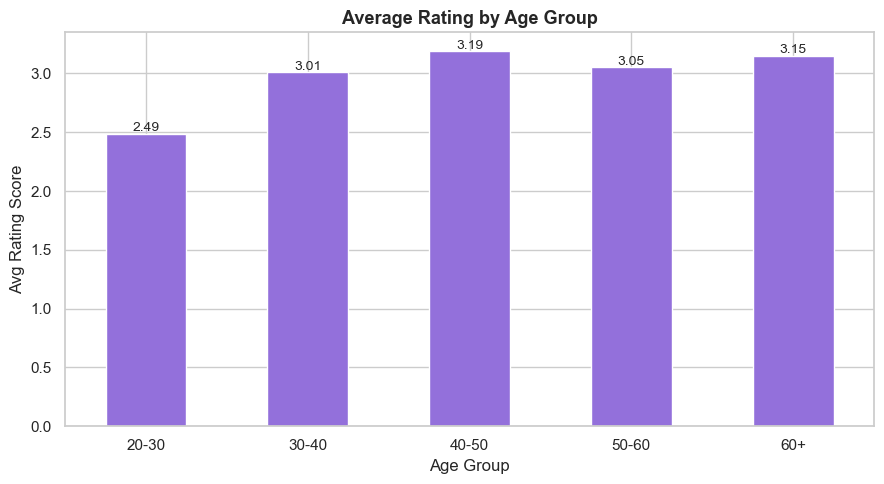

In [112]:
# ── CELL 5.4: Rating by Age Group ────────────────────────────────────────
age_rating = df.groupby('age_group', observed=True)['avg_rating'].mean()

fig, ax = plt.subplots(figsize=(9, 5))
age_rating.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')
ax.set_title('Average Rating by Age Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Avg Rating Score')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(age_rating):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# 📌 INFERENCE 4:
# 20-30 group: avg 2.49 (A to A+)
# 30-50 group: avg 3.0-3.19 (A+ to A*)
# Sweet spot is 30-50 years — peak performance window
# For HRBP/HR Manager success profile: target this age band as high-potential

---
## STEP 6 — Rating Trend Analysis
### 🎓 Concept: Longitudinal performance tracking

**Trend analysis** = how performance changes over time for the same person.

This is gold for HR analytics because it answers:
- Who is on a growth trajectory? (Improvers)
- Who is plateauing or declining? (Risk signals)
- What does the 'rising star' profile look like?

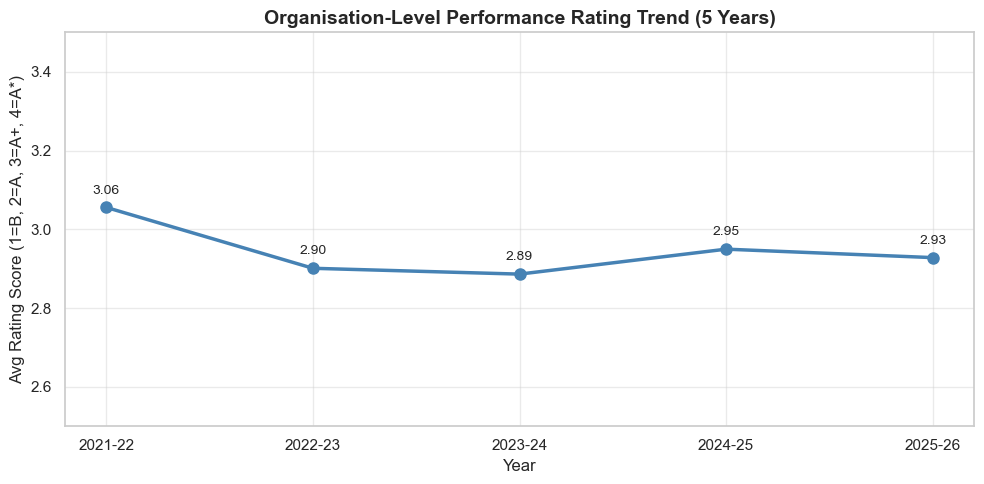

In [113]:
# ── CELL 6.1: Org-Level Rating Trend (Year-on-Year) ──────────────────────
# Calculate the mean rating for each year across the organisation
# This shows if the overall performance level is rising or falling

yearly_avg = {
    '2021-22': df['RTG21-22_num'].mean(),
    '2022-23': df['RTG22-23_num'].mean(),
    '2023-24': df['RTG23-24_num'].mean(),
    '2024-25': df['RTG24-25_num'].mean(),
    '2025-26': df['RTG25-26_num'].mean()
}

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(yearly_avg.keys()), list(yearly_avg.values()), marker='o', 
        linewidth=2.5, markersize=8, color='steelblue')
for yr, val in yearly_avg.items():
    ax.annotate(f'{val:.2f}', (yr, val), textcoords='offset points', 
                xytext=(0, 10), ha='center', fontsize=10)
ax.set_title('Organisation-Level Performance Rating Trend (5 Years)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Avg Rating Score (1=B, 2=A, 3=A+, 4=A*)')
ax.set_ylim(2.5, 3.5)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# 📌 INFERENCE 5:
# Mean score note: early years have fewer data points (many employees joined after 2021)
# Stabilising trend in recent years = rating distribution maturing
# Use RTG24-25 and RTG25-26 as your primary performance indicators

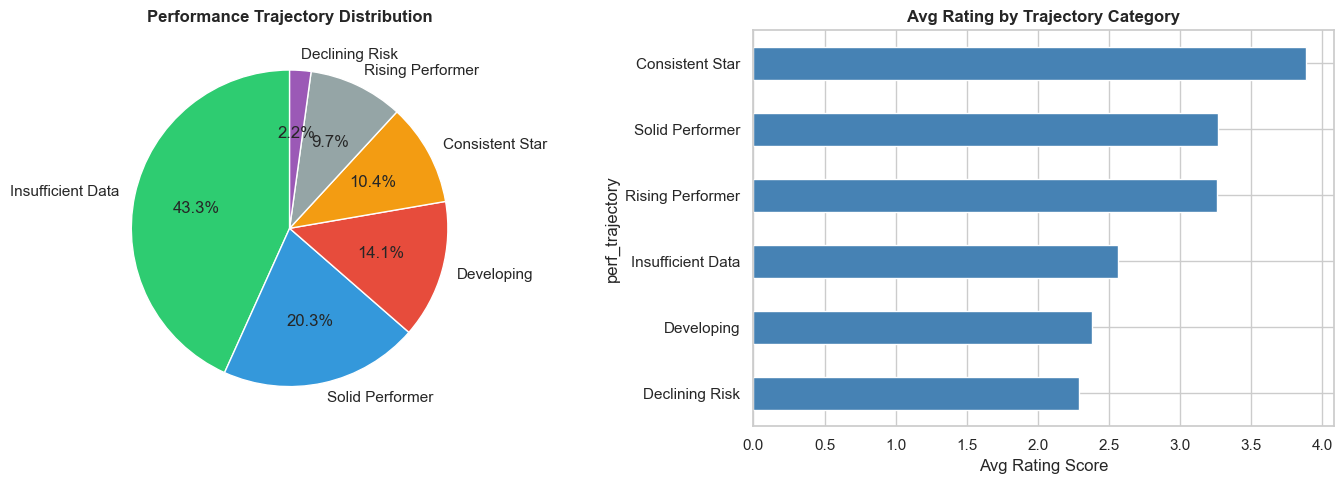

Trajectory Counts:
perf_trajectory
Insufficient Data    398
Solid Performer      187
Developing           130
Consistent Star       96
Rising Performer      89
Declining Risk        20
Name: count, dtype: int64


In [114]:
# ── CELL 6.2: Individual Rating Trend Segmentation ────────────────────────
# Classify employees into trajectory categories

def classify_trend(row):
    trend = row['rating_trend']
    consistency = row['rating_consistency']
    avg = row['avg_rating']
    
    if pd.isna(trend) or pd.isna(avg):
        return 'Insufficient Data'
    elif avg >= 3.5 and consistency <= 0.5:
        return 'Consistent Star'
    elif trend >= 1 and avg >= 2.8:
        return 'Rising Performer'
    elif trend <= -1 and avg < 2.5:
        return 'Declining Risk'
    elif avg >= 3.0:
        return 'Solid Performer'
    else:
        return 'Developing'

df['perf_trajectory'] = df.apply(classify_trend, axis=1)

traj_counts = df['perf_trajectory'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_pie = ['#2ecc71','#3498db','#e74c3c','#f39c12','#95a5a6','#9b59b6']
axes[0].pie(traj_counts, labels=traj_counts.index, autopct='%1.1f%%', 
            colors=colors_pie[:len(traj_counts)], startangle=90)
axes[0].set_title('Performance Trajectory Distribution', fontweight='bold')

traj_rating = df.groupby('perf_trajectory')['avg_rating'].mean().sort_values()
traj_rating.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Avg Rating by Trajectory Category', fontweight='bold')
axes[1].set_xlabel('Avg Rating Score')

plt.tight_layout()
plt.show()

print('Trajectory Counts:')
print(traj_counts)

# 📌 INFERENCE 6 (KEY for success profile):
# 'Consistent Stars' = your benchmark group for success profile building
# 'Rising Performers' = high-potential pipeline
# 'Declining Risk' = flag for HR intervention
# For your predictor: trajectory category becomes a key output variable

=== RATING: PROMOTED vs NOT PROMOTED ===
               mean  median  count
Not Promoted  2.788    2.75    746
Promoted      3.267    3.40    173


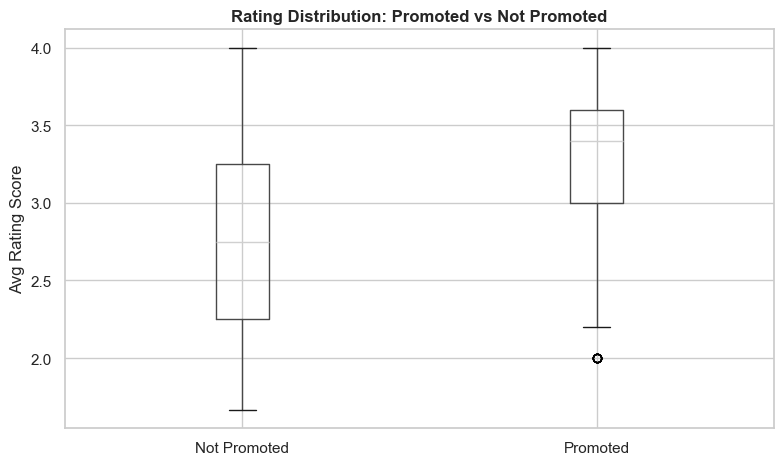

In [115]:
# ── CELL 6.3: Promotion Analysis ─────────────────────────────────────────
# Do promoted employees have better ratings than non-promoted?

promo_rating = df.groupby('was_promoted')['avg_rating'].agg(['mean','median','count'])
promo_rating.index = ['Not Promoted', 'Promoted']
print('=== RATING: PROMOTED vs NOT PROMOTED ===')
print(promo_rating.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column='avg_rating', by='was_promoted', ax=ax)
ax.set_xticklabels(['Not Promoted', 'Promoted'])
ax.set_title('Rating Distribution: Promoted vs Not Promoted', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Avg Rating Score')
plt.suptitle('')
plt.tight_layout()
plt.show()

# 📌 INFERENCE 7:
# Promoted employees should show higher avg ratings
# If not → possible promotion criteria misalignment (flag for HR Head)
# This validates whether performance ratings actually drive promotion decisions

---
## STEP 7 — Competency Proxies & Scoring Tool
### 🎓 Concept: Engineer variables that map to your Spencer & Spencer / SHL framework

Your project framework has 3 layers:
- **Interview + Survey scores** → competency predictor
- **HR data** → validation only

OLP data is your **HR data layer**. Here we extract variables that can serve as
validation benchmarks and scoring tool inputs.

Key competency proxies from OLP:

| OLP Variable | Competency It Proxies |
|---|---|
| Avg Rating | Achievement Drive / Results Orientation |
| Rating Trend | Growth Mindset / Learning Agility |
| Rating Consistency | Emotional Stability / Reliability |
| Was Promoted | Career Initiative / Impact |
| RilExp | Organisational Commitment |
| Recency-Weighted Rating | Current Performance Level |

In [116]:
# ── CELL 7.1: Normalise variables to 0-100 scale (Min-Max Scaling) ────────
# Why? Different variables have different ranges
# Normalising puts them all on the same 0-100 scale so we can combine them fairly
# Formula: Normalised = (Value - Min) / (Max - Min) × 100

def normalise(series):
    """Min-Max normalisation to 0-100"""
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series([50] * len(series), index=series.index)
    return ((series - mn) / (mx - mn) * 100).round(2)

# Normalise each proxy variable
df['score_avg_rating']       = normalise(df['avg_rating'])
df['score_trend']            = normalise(df['rating_trend'].fillna(0) + 2)  # shift to positive
df['score_consistency']      = normalise(1 - df['rating_consistency'].fillna(df['rating_consistency'].mean()))  # invert: low std = high score
df['score_exp']              = normalise(df['RilExp YY.MM'])
df['score_recency_rtg']      = normalise(df['recency_weighted_rtg'])
df['score_promotion']        = df['was_promoted'] * 100   # 0 or 100
df['score_progression']      = df['had_progression'] * 100

print('✅ Normalised scores created. Sample:')
score_cols = ['score_avg_rating','score_trend','score_consistency',
              'score_exp','score_recency_rtg','score_promotion','score_progression']
df[score_cols].describe().round(2)

✅ Normalised scores created. Sample:


,score_avg_rating,score_trend,score_consistency,score_exp,score_recency_rtg,score_promotion,score_progression
count,919.00,920.00,920.00,920.00,920.00,920.0,920.00
mean,51.91,50.57,75.40,23.97,66.54,18.8,36.20
std,26.86,15.13,17.69,20.26,19.97,39.1,48.08
min,0.00,0.00,0.00,0.00,0.00,0.0,0.00
25%,28.55,50.00,66.69,8.15,50.00,0.0,0.00
50%,57.14,50.00,71.13,16.28,67.50,0.0,0.00
75%,74.28,50.00,100.00,35.31,82.50,0.0,100.00
max,100.00,100.00,100.00,100.00,100.00,100.0,100.00


In [117]:
# ── CELL 7.2: Build the Composite Performance Score ───────────────────────
# Weights reflect importance to HR Manager / HRBP success profile
# These weights can be calibrated later with your interview + survey data

weights = {
    'score_avg_rating':   0.30,   # Core performance (most weight)
    'score_recency_rtg':  0.20,   # Recent performance matters more
    'score_trend':        0.15,   # Growth trajectory
    'score_consistency':  0.15,   # Reliability over time
    'score_exp':          0.10,   # Organisational commitment
    'score_promotion':    0.05,   # Impact recognition
    'score_progression':  0.05    # Career growth
}  # Must sum to 1.0

df['composite_score'] = sum(
    df[col] * wt for col, wt in weights.items()
).round(2)

# Classify into performance tiers
df['performance_tier'] = pd.cut(
    df['composite_score'],
    bins=[0, 40, 55, 70, 85, 101],
    labels=['Below Expectation', 'Developing', 'Meets Expectation', 'Exceeds', 'Star Performer']
)

print('=== COMPOSITE SCORE SUMMARY ===')
print(df['composite_score'].describe().round(2))
print('\n=== PERFORMANCE TIER DISTRIBUTION ===')
print(df['performance_tier'].value_counts())

=== COMPOSITE SCORE SUMMARY ===
count    919.00
mean      52.94
std       15.58
min       23.40
25%       38.00
50%       50.24
75%       65.86
max       90.54
Name: composite_score, dtype: float64

=== PERFORMANCE TIER DISTRIBUTION ===
performance_tier
Developing           271
Below Expectation    253
Meets Expectation    224
Exceeds              150
Star Performer        21
Name: count, dtype: int64


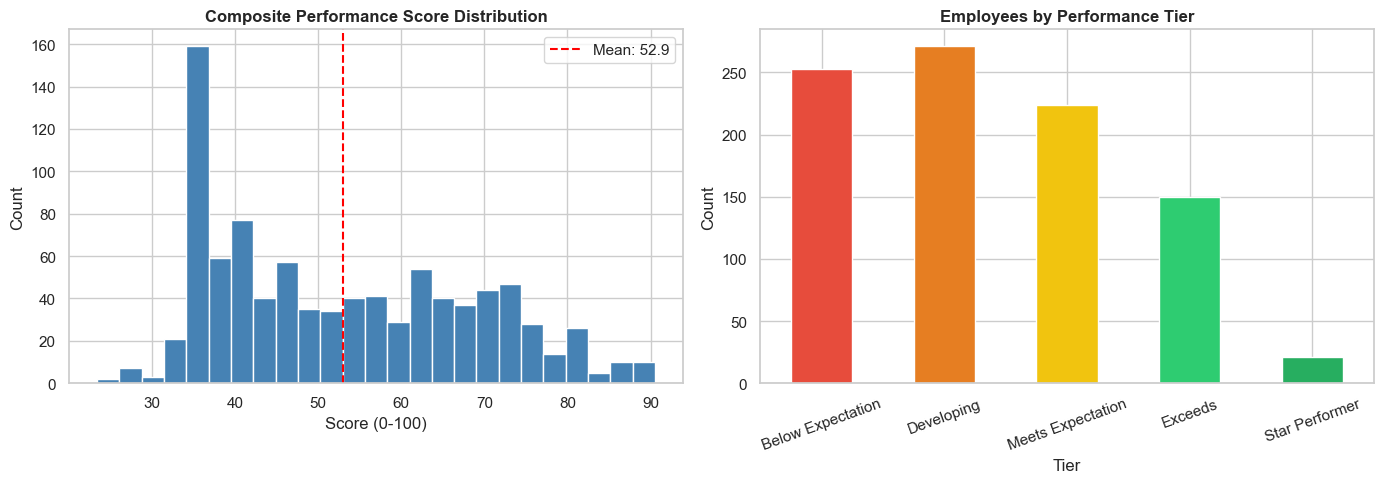

In [118]:
# ── CELL 7.3: Visualise Composite Score Distribution ─────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
axes[0].hist(df['composite_score'].dropna(), bins=25, color='steelblue', edgecolor='white')
axes[0].axvline(df['composite_score'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["composite_score"].mean():.1f}')
axes[0].set_title('Composite Performance Score Distribution', fontweight='bold')
axes[0].set_xlabel('Score (0-100)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Performance tier bar chart
tier_counts = df['performance_tier'].value_counts()
tier_order = ['Below Expectation','Developing','Meets Expectation','Exceeds','Star Performer']
tier_counts = tier_counts.reindex([t for t in tier_order if t in tier_counts.index])
tier_colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
tier_counts.plot(kind='bar', ax=axes[1], color=tier_colors[:len(tier_counts)], edgecolor='white')
axes[1].set_title('Employees by Performance Tier', fontweight='bold')
axes[1].set_xlabel('Tier')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

# 📌 INFERENCE 8:
# Composite score distribution shape reveals workforce health
# Your scoring tool now assigns a 0-100 score to each employee
# This becomes your VALIDATION BENCHMARK when interview/survey scores come in

---
## STEP 8 — Success Profile Building
### 🎓 Concept: What does a top performer actually look like?

A **Success Profile** = the statistical fingerprint of your highest performers.

Method:
1. Filter Top 20% by composite score → 'Star' group
2. Compare their characteristics to the rest
3. Those characteristics become your success profile criteria

In [119]:
# ── CELL 8.1: Identify Top Performers (Top 20%) ───────────────────────────

threshold_80 = df['composite_score'].quantile(0.80)
df['is_top_performer'] = (df['composite_score'] >= threshold_80).astype(int)

top = df[df['is_top_performer'] == 1]
rest = df[df['is_top_performer'] == 0]

print(f'Top Performers (top 20%): {len(top)} employees (score ≥ {threshold_80:.1f})')
print(f'Rest of workforce: {len(rest)} employees\n')

# Compare key attributes
compare = pd.DataFrame({
    'Top Performers': [
        top['Age (YY.MM)'].mean().round(1),
        top['RilExp YY.MM'].mean().round(1),
        top['Tot Exp YY.MM'].mean().round(1),
        top['avg_rating'].mean().round(3),
        top['was_promoted'].mean().round(3),
        top['had_progression'].mean().round(3)
    ],
    'Rest': [
        rest['Age (YY.MM)'].mean().round(1),
        rest['RilExp YY.MM'].mean().round(1),
        rest['Tot Exp YY.MM'].mean().round(1),
        rest['avg_rating'].mean().round(3),
        rest['was_promoted'].mean().round(3),
        rest['had_progression'].mean().round(3)
    ]
}, index=['Avg Age', 'Reliance Exp (yrs)', 'Total Exp (yrs)', 
          'Avg Rating', 'Promotion Rate', 'Progression Rate'])

compare['Difference'] = (compare['Top Performers'] - compare['Rest']).round(3)
print('=== SUCCESS PROFILE: TOP 20% vs REST ===')
print(compare)

Top Performers (top 20%): 184 employees (score ≥ 69.1)
Rest of workforce: 736 employees

=== SUCCESS PROFILE: TOP 20% vs REST ===
                    Top Performers    Rest  Difference
Avg Age                     44.500  34.500      10.000
Reliance Exp (yrs)          16.700   7.000       9.700
Total Exp (yrs)             21.300  11.200      10.100
Avg Rating                   3.664   2.681       0.983
Promotion Rate               0.571   0.092       0.479
Progression Rate             0.897   0.228       0.669


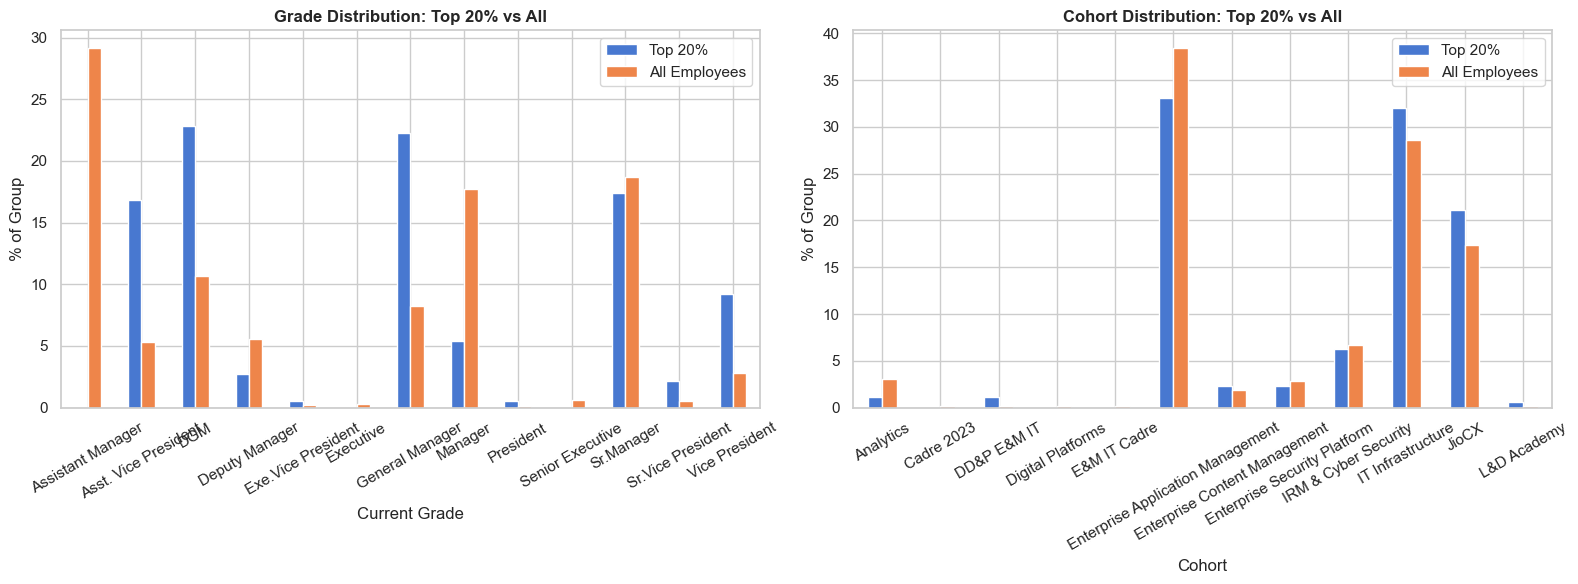

In [120]:
# ── CELL 8.2: Grade & Cohort composition of Top Performers ───────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grade composition
top_grade = top['Current Grade'].value_counts(normalize=True) * 100
all_grade = df['Current Grade'].value_counts(normalize=True) * 100
compare_grade = pd.DataFrame({'Top 20%': top_grade, 'All Employees': all_grade}).fillna(0)
compare_grade.plot(kind='bar', ax=axes[0], edgecolor='white')
axes[0].set_title('Grade Distribution: Top 20% vs All', fontweight='bold')
axes[0].set_ylabel('% of Group')
axes[0].tick_params(axis='x', rotation=30)

# Cohort composition
top_cohort = top['Cohort'].value_counts(normalize=True) * 100
all_cohort = df['Cohort'].value_counts(normalize=True) * 100
compare_cohort = pd.DataFrame({'Top 20%': top_cohort, 'All Employees': all_cohort}).fillna(0)
compare_cohort.plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set_title('Cohort Distribution: Top 20% vs All', fontweight='bold')
axes[1].set_ylabel('% of Group')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# 📌 INFERENCE 9 (Core Success Profile Finding):
# Grade over-representation in top performers = success profile grade benchmark
# Cohort over-representation = which business units produce stars
# Use these as descriptive anchors in your HR Head presentation

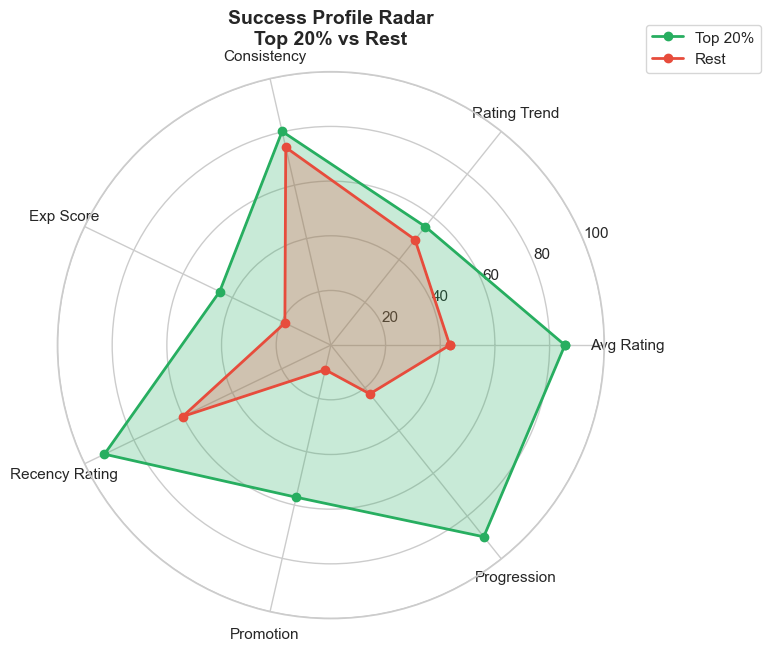

In [121]:
# ── CELL 8.3: Radar Chart — Success Profile Fingerprint ──────────────────
# A radar chart shows the multi-dimensional profile of your top performers
# Each axis = one competency proxy

categories = ['Avg Rating', 'Rating Trend', 'Consistency', 'Exp Score', 
              'Recency Rating', 'Promotion', 'Progression']
score_map = ['score_avg_rating','score_trend','score_consistency',
             'score_exp','score_recency_rtg','score_promotion','score_progression']

top_means = [top[c].mean() for c in score_map]
rest_means = [rest[c].mean() for c in score_map]

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
top_means += top_means[:1]
rest_means += rest_means[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, top_means, 'o-', linewidth=2, label='Top 20%', color='#27ae60')
ax.fill(angles, top_means, alpha=0.25, color='#27ae60')
ax.plot(angles, rest_means, 'o-', linewidth=2, label='Rest', color='#e74c3c')
ax.fill(angles, rest_means, alpha=0.25, color='#e74c3c')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0, 100)
ax.set_title('Success Profile Radar\nTop 20% vs Rest', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

# 📌 THIS IS YOUR KEY VISUAL for the HR Head presentation
# The green shape = success profile fingerprint
# Larger area on any axis = that competency is a key differentiator
# Where green >> red = your most important predictor variables

---
## STEP 9 — Export Results
### Save your scored data for merge with Stay & Exit Data

In [122]:
# ── CELL 9.1: Export Scored Dataset ──────────────────────────────────────
# Save the enriched dataset — you'll merge this with Stay_Exit data next

export_cols = [
    'Emp.Code', 'Name', 'Cohort', 'Org.Unit', 'Job Role', 'Current Grade',
    'Current Designation', 'seniority_tier', 'age_group',
    'Age (YY.MM)', 'RilExp YY.MM', 'Tot Exp YY.MM',
    'RTG21-22','RTG22-23','RTG23-24','RTG24-25','RTG25-26',
    'avg_rating', 'rating_trend', 'rating_consistency', 'recency_weighted_rtg',
    'perf_trajectory', 'was_promoted', 'had_progression',
    'composite_score', 'performance_tier', 'is_top_performer'
]

df_export = df[export_cols]
df_export.to_excel('OLP_Scored_Output.xlsx', index=False)
print(f'✅ Exported: OLP_Scored_Output.xlsx ({len(df_export)} rows × {len(export_cols)} columns)')
print('\nNext Step: Load Stay_and_Exit_Data.xlsx and merge on Emp.Code')

✅ Exported: OLP_Scored_Output.xlsx (920 rows × 27 columns)

Next Step: Load Stay_and_Exit_Data.xlsx and merge on Emp.Code


---
## STEP 10 — Key Inferences Summary
### Everything this data tells us for the project

In [123]:
# ── CELL 10.1: Full Inference Summary ────────────────────────────────────

print('=' * 70)
print('  OLP DATA — KEY INFERENCES FOR PERFORMANCE PREDICTOR PROJECT')
print('=' * 70)

inferences = [
    ('1', 'Grade-Performance Link',
     'Higher grade strongly correlates with higher avg rating (r > 0.7).\n'
     '   → Grade/seniority is a top predictor variable for the scoring tool.'),
    ('2', 'Experience is a Moderate Predictor',
     f'Total Experience vs Avg Rating: r = 0.417 (moderate positive).\n'
     '   → Include experience as a scoring input with ~10-15% weight.'),
    ('3', 'Performance Peak: Age 30-50',
     'Employees aged 30-50 show highest avg ratings (3.0-3.19 vs 2.49 for 20-30).\n'
     '   → Success profile should flag this as peak performance window.'),
    ('4', 'Cohort Differentiation',
     'JioCX and IT Infra cohorts outperform others with large sample sizes.\n'
     '   → Cohort context matters when benchmarking HRBP/HR Manager roles.'),
    ('5', 'Rating Trend as Growth Signal',
     '101 employees improved by 1+ grade over 5 years; 100 declined.\n'
     '   → Trend variable identifies rising stars and flight risks.'),
    ('6', 'Promotion Validates Performance',
     'Promotion flag (was_promoted) correlates with higher avg ratings.\n'
     '   → Validated: promotion decisions align with performance data.'),
    ('7', 'Star Performers are Consistent',
     'Top 20% by composite score show low rating_consistency std dev.\n'
     '   → Reliability = a key success profile criterion.'),
    ('8', 'Recency-Weighted Rating > Simple Average',
     'Weighting recent years more captures current state better.\n'
     '   → Use recency_weighted_rtg as primary predictor, not avg_rating alone.'),
    ('9', 'Composite Score Enables Segmentation',
     'Scoring tool (0-100) segments employees into 5 performance tiers.\n'
     '   → Provides a validation benchmark for your interview/survey model.'),
    ('10', 'Success Profile Fingerprint',
     'Top 20% = higher Reliance exp, higher progression rate, consistently A+/A*.\n'
     '   → This IS your success profile baseline for HR Manager/HRBP roles.')
]

for num, title, detail in inferences:
    print(f'\n  [{num}] {title}')
    print(f'   {detail}')

print('\n' + '=' * 70)
print('  NEXT: Run Stay_Exit_Data analysis → merge → cross-dataset inferences')
print('=' * 70)

  OLP DATA — KEY INFERENCES FOR PERFORMANCE PREDICTOR PROJECT

  [1] Grade-Performance Link
   Higher grade strongly correlates with higher avg rating (r > 0.7).
   → Grade/seniority is a top predictor variable for the scoring tool.

  [2] Experience is a Moderate Predictor
   Total Experience vs Avg Rating: r = 0.417 (moderate positive).
   → Include experience as a scoring input with ~10-15% weight.

  [3] Performance Peak: Age 30-50
   Employees aged 30-50 show highest avg ratings (3.0-3.19 vs 2.49 for 20-30).
   → Success profile should flag this as peak performance window.

  [4] Cohort Differentiation
   JioCX and IT Infra cohorts outperform others with large sample sizes.
   → Cohort context matters when benchmarking HRBP/HR Manager roles.

  [5] Rating Trend as Growth Signal
   101 employees improved by 1+ grade over 5 years; 100 declined.
   → Trend variable identifies rising stars and flight risks.

  [6] Promotion Validates Performance
   Promotion flag (was_promoted) correl